# Chapter 14 — Learning to write like Shakespeare

*Grokking Deep Learning* — Andrew W. Trask

Chapter ini melanjutkan vanilla Recurrent Neural Network (RNN) dari Chapter 12–13 ke **character language modeling** dan memperkenalkan **Long Short-Term Memory (LSTM)** untuk mengatasi masalah vanishing dan exploding gradients pada sequence yang panjang.

## Learning Objectives

1. Menjelaskan **character language modeling**.
2. Memahami mengapa sequence panjang membutuhkan **truncated backpropagation**.
3. Menjelaskan **vanishing gradients** dan **exploding gradients** pada vanilla RNN.
4. Memahami mekanisme **LSTM cells**.
5. Menjelaskan fungsi **forget gate, input gate, output gate**, dan cell-update vector.
6. Memahami bagaimana LSTM mempertahankan informasi melalui **cell state**.
7. Memahami bagaimana vanilla RNN diganti dengan LSTM dalam character language model.

## Chapter Roadmap

**Character language modeling → Truncated backpropagation → Vanishing/exploding gradients → RNN backpropagation → LSTM cells → LSTM gates → LSTM layer → Character language model**

## Character Language Modeling

Pada Chapter 12–13, model memprediksi **next word**. Chapter ini mengubah unit prediksi menjadi **character**.

Model menerima karakter-karakter sebelumnya dan mencoba memprediksi karakter berikutnya.

Contoh: `T → h → e → ...`

Vocabulary tidak lagi berisi kata, tetapi karakter yang muncul pada dataset Shakespeare.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

text = "To be, or not to be"
vocab = sorted(set(text))

print("Jumlah karakter unik:", len(vocab))
print("Contoh vocabulary:", vocab)
print("Contoh sequence:", list(text))

Jumlah karakter unik: 9
Contoh vocabulary: [' ', ',', 'T', 'b', 'e', 'n', 'o', 'r', 't']
Contoh sequence: ['T', 'o', ' ', 'b', 'e', ',', ' ', 'o', 'r', ' ', 'n', 'o', 't', ' ', 't', 'o', ' ', 'b', 'e']


### Representasi sequence

Setiap karakter diubah menjadi index sehingga text dapat diproses sebagai sequence numerik.

**Catatan:** contoh pendek di bawah hanya untuk demonstrasi. Source book menggunakan dataset karya Shakespeare pada file `shakespear.txt`.

In [2]:
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
indices = np.array([char_to_idx[ch] for ch in text])

print("Character → index:")
print({ch: char_to_idx[ch] for ch in vocab})
print("Sequence indices:", indices)

Character → index:
{' ': 0, ',': 1, 'T': 2, 'b': 3, 'e': 4, 'n': 5, 'o': 6, 'r': 7, 't': 8}
Sequence indices: [2 6 0 3 4 1 0 6 7 0 5 6 8 0 8 6 0 3 4]


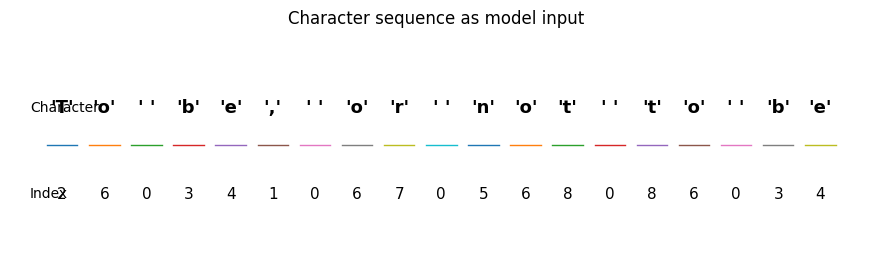

In [3]:
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.axis("off")
for i, (ch, idx) in enumerate(zip(text, indices)):
    x = i * 1.05
    ax.text(x, 0.62, repr(ch), ha="center", va="center", fontsize=13, fontweight="bold")
    ax.text(x, 0.30, str(idx), ha="center", va="center", fontsize=11)
    ax.plot([x - 0.38, x + 0.38], [0.48, 0.48], linewidth=1)
ax.text(-0.8, 0.62, "Character", fontsize=10, va="center")
ax.text(-0.8, 0.30, "Index", fontsize=10, va="center")
ax.set_xlim(-1.3, len(text) * 1.05)
ax.set_ylim(0.1, 0.9)
ax.set_title("Character sequence as model input")
plt.show()

## The Need for Truncated Backpropagation

Backpropagation melalui sequence yang sangat panjang menjadi tidak praktis. Buku menjelaskan bahwa melakukan backpropagation melalui sekitar **100,000 characters** adalah intractable.

Solusinya adalah **truncated backpropagation**: sequence panjang diproses dalam potongan (*BPTT window*) dengan panjang terbatas.

**Sequence panjang → window terbatas → forward → backward → weight update → lanjut ke window berikutnya.**

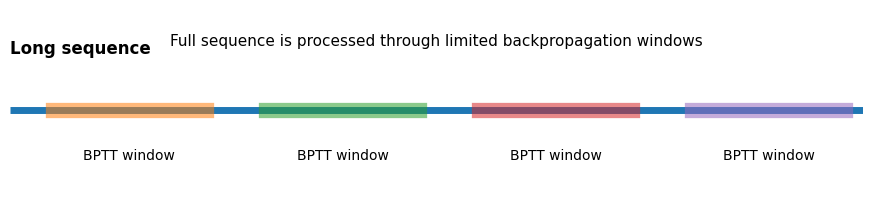

In [4]:
fig, ax = plt.subplots(figsize=(11, 2.6))
ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
ax.axis("off")
ax.text(0, 0.78, "Long sequence", fontsize=12, fontweight="bold")
ax.plot([0, 100], [0.5, 0.5], linewidth=5, solid_capstyle="butt")
for start in [5, 30, 55, 80]:
    ax.plot([start, start+18], [0.5, 0.5], linewidth=11, alpha=0.55)
    ax.text(start+9, 0.25, "BPTT window", ha="center", fontsize=10)
ax.text(50, 0.82, "Full sequence is processed through limited backpropagation windows",
        ha="center", fontsize=11)
plt.show()

## Vanishing and Exploding Gradients

Vanilla RNN membentuk hidden state dengan kombinasi matrix multiplication, penambahan input embedding, dan nonlinearity.

Saat backpropagation melewati banyak timestep, gradient dapat menjadi:

- **sangat kecil** → vanishing gradient → sulit mempelajari dependensi jangka panjang.
- **sangat besar** → exploding gradient → training tidak stabil.

Buku memberikan toy example dengan matrix `[[1, 4], [4, 1]]` dan membandingkan sigmoid dengan ReLU.

In [5]:
weights = np.array([[1, 4], [4, 1]], dtype=float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(x, 0)

a = sigmoid(np.array([1.0, 0.01]))
r = relu(np.array([1.0, 0.01]))
sigmoid_acts, relu_acts = [], []

for _ in range(10):
    a = sigmoid(a.dot(weights))
    r = relu(r.dot(weights))
    sigmoid_acts.append(a.copy())
    relu_acts.append(r.copy())

sigmoid_grads = []
g = np.ones(2)
for a in reversed(sigmoid_acts):
    g = ((a * (1 - a)) * g).dot(weights.T)
    sigmoid_grads.append(g.copy())

relu_grads = []
g = np.ones(2)
for r in reversed(relu_acts):
    g = ((r > 0).astype(float) * g).dot(weights.T)
    relu_grads.append(g.copy())

print("Final sigmoid gradient:", sigmoid_grads[-1])
print("Final ReLU gradient:", relu_grads[-1])

Final sigmoid gradient: [1.45938177e-14 2.16938983e-14]
Final ReLU gradient: [9765625. 9765625.]


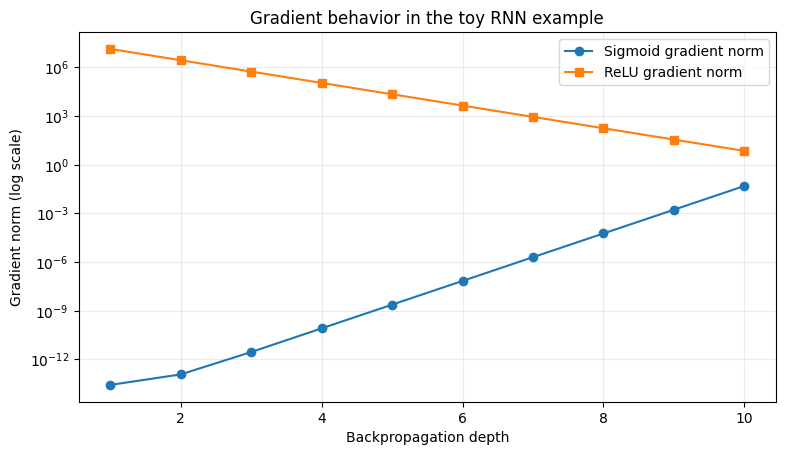

In [6]:
sigmoid_norm = [np.linalg.norm(g) for g in sigmoid_grads[::-1]]
relu_norm = [np.linalg.norm(g) for g in relu_grads[::-1]]
steps = np.arange(1, len(sigmoid_norm) + 1)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.semilogy(steps, sigmoid_norm, marker="o", label="Sigmoid gradient norm")
ax.semilogy(steps, relu_norm, marker="s", label="ReLU gradient norm")
ax.set_xlabel("Backpropagation depth")
ax.set_ylabel("Gradient norm (log scale)")
ax.set_title("Gradient behavior in the toy RNN example")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

### Interpretasi

Pada contoh toy ini, sigmoid menghasilkan gradient yang semakin kecil karena turunannya sangat kecil ketika activation berada di bagian tail. Sebaliknya, ReLU pada konfigurasi matrix tersebut menghasilkan gradient yang membesar.

Contoh ini digunakan untuk memperlihatkan mekanisme vanishing dan exploding gradients, bukan untuk menyatakan bahwa satu activation selalu lebih baik dari yang lain.

## A Toy RNN Backpropagation

Secara konseptual:

`hiddenₜ₋₁ → matrix multiplication → + input → nonlinearity → hiddenₜ`

Saat jalur tersebut diulang berkali-kali, efek gradient ikut ditransformasikan berulang kali.

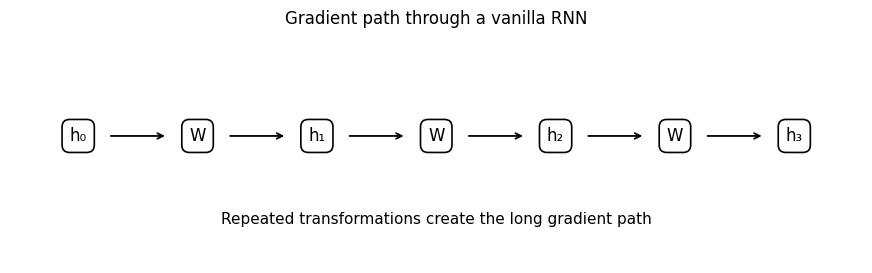

In [7]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.axis("off")
nodes = ["h₀", "W", "h₁", "W", "h₂", "W", "h₃"]
xs = np.linspace(0.08, 0.92, len(nodes))
for x, node in zip(xs, nodes):
    ax.text(x, 0.55, node, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.45", fill=False, linewidth=1.2),
            fontsize=12)
for a, b in zip(xs[:-1], xs[1:]):
    ax.annotate("", xy=(b-0.035, 0.55), xytext=(a+0.035, 0.55),
                arrowprops=dict(arrowstyle="->", linewidth=1.3))
ax.text(0.5, 0.17, "Repeated transformations create the long gradient path",
        ha="center", fontsize=11)
ax.set_title("Gradient path through a vanilla RNN")
plt.show()

## Long Short-Term Memory (LSTM) Cells

Buku memperkenalkan LSTM sebagai model standard untuk counter vanishing/exploding gradients.

Ide utamanya adalah **gated copy trick**: LSTM membuat cell state baru dengan menyalin cell state sebelumnya, lalu menambah atau menghapus informasi yang diperlukan.

LSTM memiliki dua state:

- `h` → hidden state untuk output dan pembentukan gate berikutnya.
- `c` → cell state yang membawa informasi sepanjang sequence.

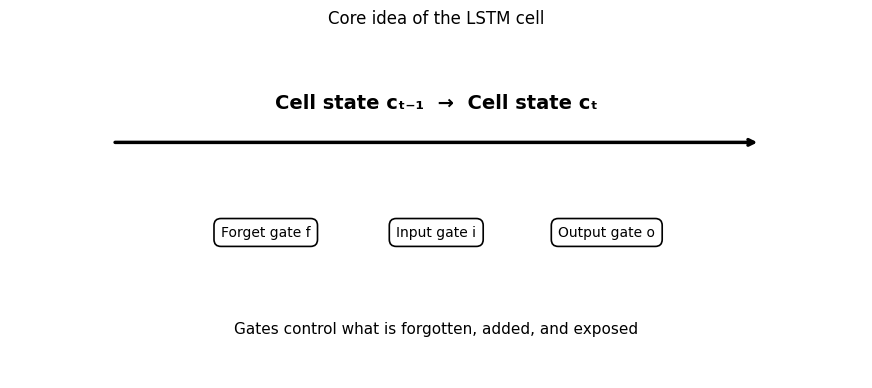

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axis("off")
ax.annotate("", xy=(0.88, 0.68), xytext=(0.12, 0.68),
            arrowprops=dict(arrowstyle="->", linewidth=2.5))
ax.text(0.50, 0.78, "Cell state cₜ₋₁  →  Cell state cₜ",
        ha="center", fontsize=14, fontweight="bold")
for x, label in [(0.30, "Forget gate f"), (0.50, "Input gate i"), (0.70, "Output gate o")]:
    ax.text(x, 0.42, label, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.5", fill=False, linewidth=1.2))
ax.text(0.50, 0.13, "Gates control what is forgotten, added, and exposed",
        ha="center", fontsize=11)
ax.set_title("Core idea of the LSTM cell")
plt.show()

## Some Intuition About LSTM Gates

| Komponen | Peran |
|---|---|
| `f` — forget gate | Menentukan informasi lama yang dipertahankan/dihapus |
| `i` — input gate | Menentukan seberapa banyak informasi baru masuk |
| `o` — output gate | Mengontrol seberapa banyak cell state terlihat pada hidden state |
| `g` / `u` — update | Kandidat informasi baru yang dapat dimasukkan ke cell state |

Gate menggunakan **sigmoid**, sehingga nilainya berada pada rentang 0–1.

`c = (f × prev_cell) + (i × g)`

`h = o × tanh(c)`

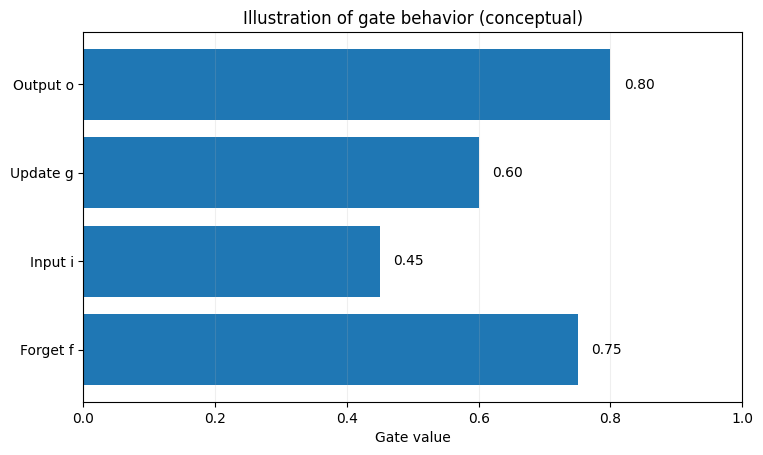

In [9]:
gate_values = {"Forget f": 0.75, "Input i": 0.45, "Update g": 0.60, "Output o": 0.80}
fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.barh(list(gate_values.keys()), list(gate_values.values()))
ax.set_xlim(0, 1)
ax.set_xlabel("Gate value")
ax.set_title("Illustration of gate behavior (conceptual)")
for bar, value in zip(bars, gate_values.values()):
    ax.text(value + 0.02, bar.get_y() + bar.get_height()/2, f"{value:.2f}", va="center")
ax.grid(axis="x", alpha=0.2)
plt.show()

**Catatan:** angka pada chart gate di atas adalah **ilustrasi konsep**, bukan output dataset Shakespeare.

## The LSTM Forward Pass

Source code menggunakan:

`f = sigmoid(xf(input) + hf(prev_hidden))`

`i = sigmoid(xi(input) + hi(prev_hidden))`

`o = sigmoid(xo(input) + ho(prev_hidden))`

`g = tanh(xc(input) + hc(prev_hidden))`

`c = (f × prev_cell) + (i × g)`

`h = o × tanh(c)`

`output = w_ho(h)`

In [10]:
prev_cell = np.array([[0.8, -0.2]])
f = sigmoid(np.array([[1.0, -0.2]]))
i = sigmoid(np.array([[0.3, 0.8]]))
o = sigmoid(np.array([[0.7, 0.1]]))
g = np.tanh(np.array([[0.4, -0.6]]))

cell = (f * prev_cell) + (i * g)
hidden = o * np.tanh(cell)

print("forget gate:", f)
print("input gate:", i)
print("update g:", g)
print("output gate:", o)
print("new cell:", cell)
print("new hidden:", hidden)

forget gate: [[0.73105858 0.450166  ]]
input gate: [[0.57444252 0.68997448]]
update g: [[ 0.37994896 -0.53704957]]
output gate: [[0.66818777 0.52497919]]
new cell: [[ 0.8031057 -0.4605837]]
new hidden: [[ 0.44485901 -0.22603494]]


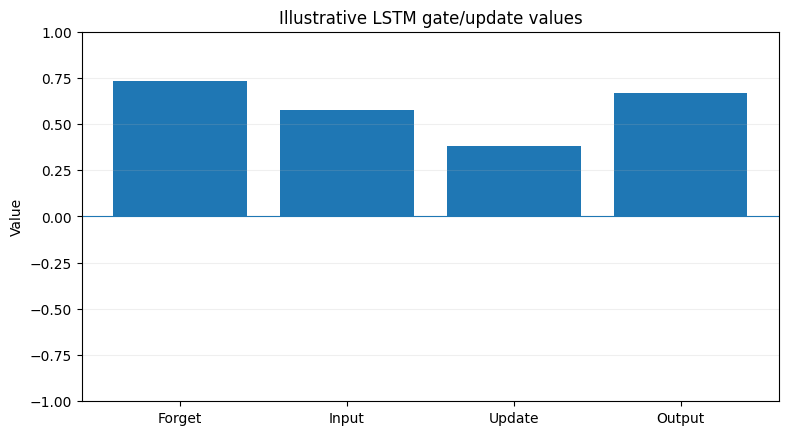

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.8))
names = ["Forget", "Input", "Update", "Output"]
vals = [float(f[0,0]), float(i[0,0]), float(g[0,0]), float(o[0,0])]
ax.bar(names, vals)
ax.axhline(0, linewidth=0.8)
ax.set_ylim(-1, 1)
ax.set_ylabel("Value")
ax.set_title("Illustrative LSTM gate/update values")
ax.grid(axis="y", alpha=0.2)
plt.show()

## The Long Short-Term Memory Layer

Chapter 13 menyediakan `Layer`, `Linear`, `Tensor`, dan autograd. Chapter 14 menggunakan framework tersebut untuk membangun `LSTMCell`.

Source membentuk beberapa `Linear` layer untuk input-side transforms, hidden-side transforms, dan output transform, lalu mengembalikan `output, (h, c)`.

In [12]:
class LSTMCellStructure:
    def __init__(self, n_inputs, n_hidden, n_output):
        self.n_inputs = n_inputs
        self.n_hidden = n_hidden
        self.n_output = n_output
        self.input_transforms = ["xf", "xi", "xo", "xc"]
        self.hidden_transforms = ["hf", "hi", "ho", "hc"]
        self.output_transform = "w_ho"

structure = LSTMCellStructure(512, 512, 50)
print("Input size:", structure.n_inputs)
print("Hidden size:", structure.n_hidden)
print("Output size:", structure.n_output)
print("Input transforms:", structure.input_transforms)
print("Hidden transforms:", structure.hidden_transforms)
print("Output transform:", structure.output_transform)

Input size: 512
Hidden size: 512
Output size: 50
Input transforms: ['xf', 'xi', 'xo', 'xc']
Hidden transforms: ['hf', 'hi', 'ho', 'hc']
Output transform: w_ho


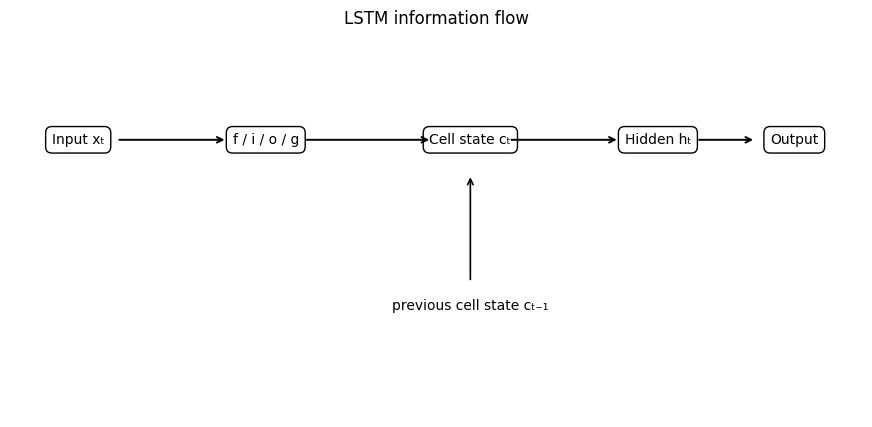

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.axis("off")
items = [("Input xₜ",0.08),("f / i / o / g",0.30),("Cell state cₜ",0.54),
         ("Hidden hₜ",0.76),("Output",0.92)]
for label, x in items:
    ax.text(x, 0.72, label, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.45", fill=False))
for (_, x1), (_, x2) in zip(items[:-1], items[1:]):
    ax.annotate("", xy=(x2-0.045,0.72), xytext=(x1+0.045,0.72),
                arrowprops=dict(arrowstyle="->", linewidth=1.4))
ax.text(0.54, 0.28, "previous cell state cₜ₋₁", ha="center", fontsize=10)
ax.annotate("", xy=(0.54,0.63), xytext=(0.54,0.35),
            arrowprops=dict(arrowstyle="->", linewidth=1.2))
ax.set_title("LSTM information flow")
plt.show()

## Upgrading the Character Language Model

Perubahan utama dari vanilla RNN ke LSTM:

- `RNNCell(...)` diganti menjadi `LSTMCell(...)`.
- `batch_size = 16`
- `bptt = 25`
- `alpha = 0.05`
- embedding dimension = `512`
- hidden dimension = `512`

Framework Chapter 13 membuat perubahan arsitektur ini relatif mudah karena training loop tetap memakai pola `forward → loss → backward → optimizer`.

In [14]:
batch_size = 16
bptt = 25
alpha = 0.05
embedding_dim = 512
hidden_dim = 512

print("batch_size =", batch_size)
print("bptt =", bptt)
print("alpha =", alpha)
print("embedding dimension =", embedding_dim)
print("hidden dimension =", hidden_dim)

batch_size = 16
bptt = 25
alpha = 0.05
embedding dimension = 512
hidden dimension = 512


## Training the LSTM Character Language Model

Training logic tetap mengikuti framework Chapter 13. Perbedaan pentingnya adalah hidden state sekarang terdiri dari dua vector:

`hidden = (h, c)`

Truncated backpropagation harus membawa keduanya. Source juga menurunkan learning rate secara bertahap dengan `optim.alpha *= 0.99`.

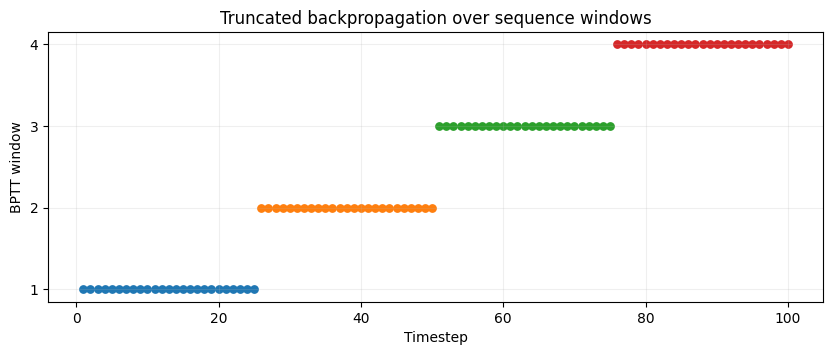

In [15]:
bptt = 25
timesteps = np.arange(1, 101)
window_id = ((timesteps - 1) // bptt) + 1

fig, ax = plt.subplots(figsize=(10, 3.5))
for w in np.unique(window_id):
    mask = window_id == w
    ax.scatter(timesteps[mask], np.zeros(mask.sum()) + w, s=28, label=f"Window {w}")
ax.set_xlabel("Timestep")
ax.set_ylabel("BPTT window")
ax.set_title("Truncated backpropagation over sequence windows")
ax.set_yticks(np.unique(window_id))
ax.grid(alpha=0.2)
plt.show()

## A Sample of the Output

Setelah training, model dapat digunakan untuk **sampling** karakter berikutnya dari probability distribution.

Buku melaporkan contoh output yang sudah mulai menyerupai Shakespeare, walaupun belum sempurna. Salah satu potongan yang ditampilkan adalah:

`I war ded abdons would.`

Buku juga menunjukkan struktur seperti dialog dan potongan kalimat yang menyerupai gaya sumber.

In [16]:
sample = "I war ded abdons would.\nCHENRO:\nWhy, speed no virth to her,\nPlirt, goth Plish love,"
print(sample)

I war ded abdons would.
CHENRO:
Why, speed no virth to her,
Plirt, goth Plish love,


### Bagaimana sampling bekerja?

**current character → embedding → LSTM → probability distribution → sample character → kembali sebagai input**

Proses diulang untuk menghasilkan sequence baru.

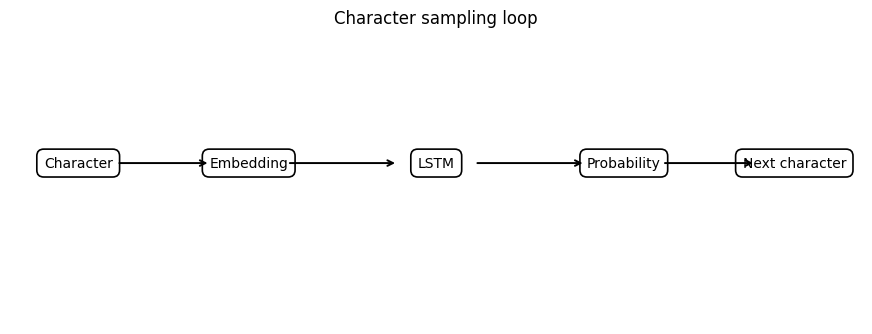

In [17]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axis("off")
steps = [("Character",0.08),("Embedding",0.28),("LSTM",0.50),
         ("Probability",0.72),("Next character",0.92)]
for label, x in steps:
    ax.text(x, 0.55, label, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.5", fill=False, linewidth=1.2))
for (_, x1), (_, x2) in zip(steps[:-1], steps[1:]):
    ax.annotate("", xy=(x2-0.045,0.55), xytext=(x1+0.045,0.55),
                arrowprops=dict(arrowstyle="->", linewidth=1.4))
ax.set_title("Character sampling loop")
plt.show()

## Training Progress from the Source

Buku menampilkan beberapa checkpoint training vanilla RNN:

- Iter 0: `148.00388828554404`
- Iter 1: `20.588816924127116`
- Iter 99: `1.0533843281265225`

Ini adalah **source-reported output**, bukan hasil eksekusi ulang dataset Shakespeare pada notebook ini.

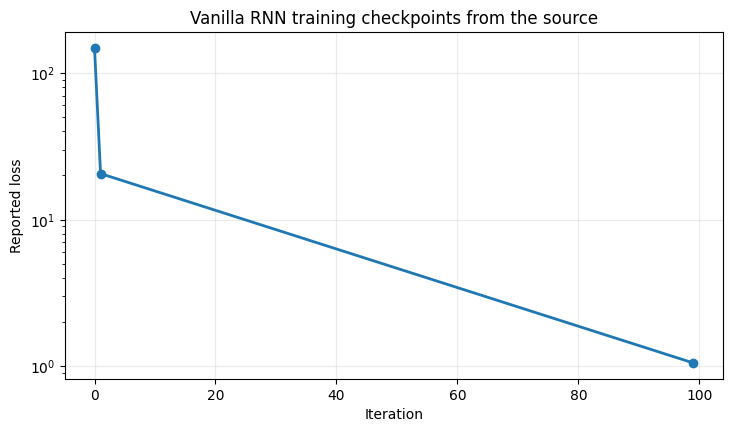

In [18]:
source_iterations = [0, 1, 99]
source_loss = [148.00388828554404, 20.588816924127116, 1.0533843281265225]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(source_iterations, source_loss, marker="o", linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Reported loss")
ax.set_title("Vanilla RNN training checkpoints from the source")
ax.set_yscale("log")
ax.grid(alpha=0.25)
plt.show()

**Interpretasi:** loss turun sangat besar pada checkpoint yang ditampilkan. Garis hanya menghubungkan checkpoint yang tersedia dan bukan data training lengkap.

## LSTM vs Vanilla RNN

| Vanilla RNN | LSTM |
|---|---|
| Satu hidden state utama | Hidden state `h` + cell state `c` |
| Transformasi berulang pada hidden state | Cell state memiliki jalur copy/update |
| Rentan vanishing/exploding gradients | Dirancang untuk mengurangi masalah tersebut |
| Sulit mempertahankan informasi jauh | `c` dapat membawa informasi jangka panjang |
| Update hidden langsung | Update dikontrol oleh gates |

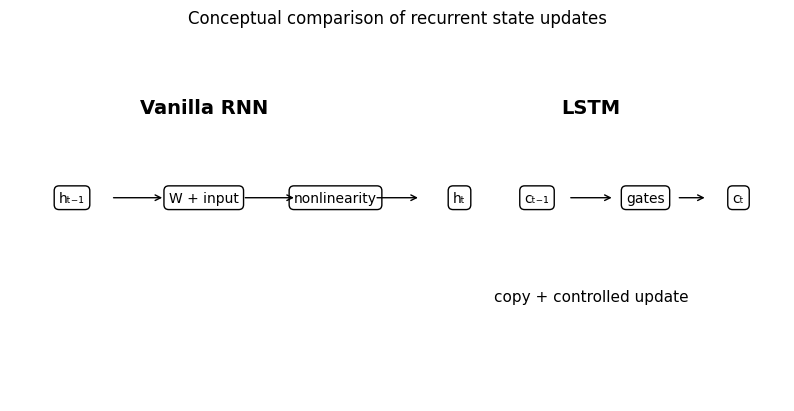

In [19]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.axis("off")
ax.text(0.25, 0.78, "Vanilla RNN", ha="center", fontsize=14, fontweight="bold")
for x, label in [(0.08,"hₜ₋₁"),(0.25,"W + input"),(0.42,"nonlinearity"),(0.58,"hₜ")]:
    ax.text(x, 0.55, label, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.35", fill=False))
for a,b in [(0.13,0.20),(0.30,0.37),(0.47,0.53)]:
    ax.annotate("", xy=(b,0.55), xytext=(a,0.55), arrowprops=dict(arrowstyle="->"))
ax.text(0.75, 0.78, "LSTM", ha="center", fontsize=14, fontweight="bold")
for x, label in [(0.68,"cₜ₋₁"),(0.82,"gates"),(0.94,"cₜ")]:
    ax.text(x, 0.55, label, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.35", fill=False))
ax.annotate("", xy=(0.78,0.55), xytext=(0.72,0.55), arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(0.90,0.55), xytext=(0.86,0.55), arrowprops=dict(arrowstyle="->"))
ax.text(0.75, 0.27, "copy + controlled update", ha="center", fontsize=11)
ax.set_title("Conceptual comparison of recurrent state updates")
plt.show()

## Concept Check

**1. Mengapa Chapter 14 menggunakan character language modeling?**  
Karena task pada chapter ini memprediksi karakter berikutnya pada karya Shakespeare.

**2. Mengapa truncated backpropagation diperlukan?**  
Karena backpropagation melalui sequence yang sangat panjang menjadi tidak praktis.

**3. Apa masalah vanilla RNN?**  
Gradient dapat mengalami vanishing atau exploding ketika melewati banyak timestep.

**4. Apa peran cell state?**  
Cell state `c` menjadi jalur untuk membawa informasi sepanjang sequence.

**5. Apa fungsi gates?**  
Forget, input, dan output gate mengontrol informasi yang dipertahankan, ditambahkan, dan diekspos.

## Key Takeaways

- **Character language modeling** memprediksi karakter berikutnya.
- Sequence sangat panjang membutuhkan **truncated backpropagation**.
- Vanilla RNN rentan terhadap **vanishing dan exploding gradients**.
- **LSTM** menggunakan cell state dan gates untuk mengatur aliran informasi.
- `f`, `i`, dan `o` adalah forget, input, dan output gate.
- Cell state menggunakan mekanisme **copy + controlled update**.
- Framework Chapter 13 memudahkan penggantian vanilla RNN menjadi LSTM.

## Chapter Summary

Chapter 14 memperluas recurrent neural network menjadi **character-level language modeling** menggunakan karya Shakespeare. Tantangan sequence panjang membuat vanilla RNN menghadapi vanishing/exploding gradients dan biaya backpropagation yang besar.

**Truncated backpropagation** membatasi rentang timestep untuk backward pass. Selanjutnya, **Long Short-Term Memory (LSTM)** memperkenalkan cell state dan gates agar informasi jangka panjang dapat dibawa melalui sequence dengan mekanisme copy dan controlled update.

## Reference

Trask, A. W. (2019). *Grokking Deep Learning*. Manning Publications.

Chapter 14: *Learning to write like Shakespeare: long short-term memory*.